# Accuracy-Efficiency Bubble Plot

This notebook plots RFNE against inference time per interpolated frame, with bubble area scaled by model parameter count. Lower-left is better.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter


# Save into ./analysis when running from the repo root; otherwise save next to the notebook.
OUTPUT_DIR = Path("analysis") if Path("analysis").is_dir() else Path(".")
OUTPUT_DIR

PosixPath('.')

## Data

Edit this table with updated inference time, RFNE, or parameter counts as needed.

In [2]:
# nkst re=12000

df = pd.DataFrame(
    {
        "model": ["U-Net", "Super SloMo", "EDEN", "iFLEX"],
        "inference_time_s": [0.24, 0.26, 0.38, 0.42],
        "rfne_pct": [34.07, 14.93, 12.53, 3.79],
        "params_m": [260.33, 39.59, 194.00, 110.2],
    }
)

df

,model,inference_time_s,rfne_pct,params_m
0,U-Net,0.24,34.07,260.33
1,Super SloMo,0.26,14.93,39.59
2,EDEN,0.38,12.53,194.00
3,iFLEX,0.42,3.79,110.20


## Plot

Saved efficiency_bubble_plot.pdf
Saved efficiency_bubble_plot.png


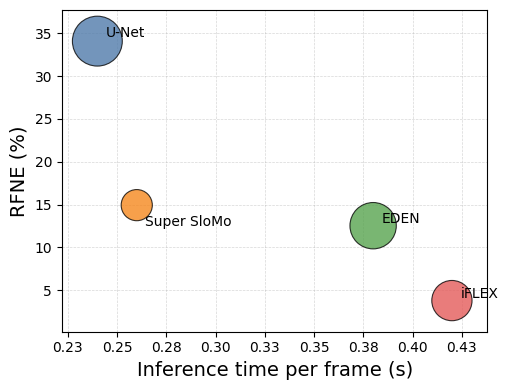

In [3]:
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 14, # 12,
        "axes.titlesize": 13,
        "legend.fontsize": 9,
        "legend.title_fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

models = df["model"].to_numpy()
inference_time = df["inference_time_s"].to_numpy(dtype=float)
rfne = df["rfne_pct"].to_numpy(dtype=float)
params_m = df["params_m"].to_numpy(dtype=float)

# Sqrt scaling keeps very large models from visually dominating the figure.
bubble_size = 80 * np.sqrt(params_m)

fig, ax = plt.subplots(figsize=(5.2, 4.0))

colors = ["#4c78a8", "#f58518", "#54a24b", "#e45756"]
ax.scatter(
    inference_time,
    rfne,
    s=bubble_size,
    c=colors[: len(df)],
    alpha=0.78,
    edgecolors="black",
    linewidths=0.8,
)

label_offsets = {
    "U-Net": (6, 6),
    "Super SloMo": (6, -12),
    "EDEN": (6, 5),
    "iFLEX": (6, 5),
}

for model, x, y in zip(models, inference_time, rfne):
    ax.annotate(
        model,
        (x, y),
        textcoords="offset points",
        xytext=label_offsets.get(model, (6, 5)),
        ha="left",
        va="center",
        fontsize=10,
    )

ax.set_xlabel("Inference time per frame (s)")
# ax.set_ylabel(r"RFNE (%) $\downarrow$")
ax.set_ylabel(r"RFNE (%)")
# ax.set_title("Accuracy-Efficiency Trade-off")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

x_margin = 0.10 * (inference_time.max() - inference_time.min() + 1e-8)
y_margin = 0.12 * (rfne.max() - rfne.min() + 1e-8)
ax.set_xlim(inference_time.min() - x_margin, inference_time.max() + x_margin)
ax.set_ylim(rfne.min() - y_margin, rfne.max() + y_margin)
ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
# ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

# ax.annotate(
#     "Better",
#     xy=(inference_time.min(), rfne.min()),
#     xytext=(inference_time.min() + 0.08, rfne.min() + 8),
#     arrowprops=dict(arrowstyle="->", lw=1.2),
#     fontsize=10,
# )

# legend_sizes = [40, 100, 250]
# legend_handles = [
#     ax.scatter(
#         [],
#         [],
#         s=80 * np.sqrt(size),
#         edgecolors="black",
#         facecolors="none",
#         linewidths=0.8,
#     )
#     for size in legend_sizes
# ]

# ax.legend(
#     legend_handles,
#     [f"{size}M params" for size in legend_sizes],
#     title="Model size",
#     loc="upper right",
#     frameon=True,
# )

fig.tight_layout()

pdf_path = OUTPUT_DIR / "efficiency_bubble_plot.pdf"
png_path = OUTPUT_DIR / "efficiency_bubble_plot.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved {pdf_path}")
print(f"Saved {png_path}")

plt.show()